In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def generate_positions(num_clients=2000, num_facilities=200, mode="uniform"):
    match mode:
        case "uniform":
            cli_pos = np.random.rand(num_clients, 2)
            fac_pos = np.random.rand(num_facilities, 2)
            return cli_pos, fac_pos

        case "clustered":
            num_clusters = np.sqrt(num_clients).astype(int)
            cluster_centers = np.random.rand(num_clusters, 2)
            clients_per_cluster = np.random.rand(num_clusters)
            clients_per_cluster *=  num_clients / clients_per_cluster.sum()
            cli_pos = np.vstack([
                center +  np.random.normal(0, 0.05, size=(int(np.round(n)), 2))
                for center, n in zip(cluster_centers, clients_per_cluster)
            ])
            fac_pos = np.random.rand(num_facilities, 2)
            return cli_pos, fac_pos


In [3]:
def plot_positions(cli_pos, fac_pos):
    plt.figure(figsize=(10, 10))
    plt.scatter(cli_pos[:, 0], cli_pos[:, 1], c='blue', s=10, alpha=0.5, label='Clients')
    plt.scatter(fac_pos[:, 0], fac_pos[:, 1], c='red', s=50, alpha=0.8, label='Facilities')
    plt.legend()
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Client and Facility Positions')
    plt.show()

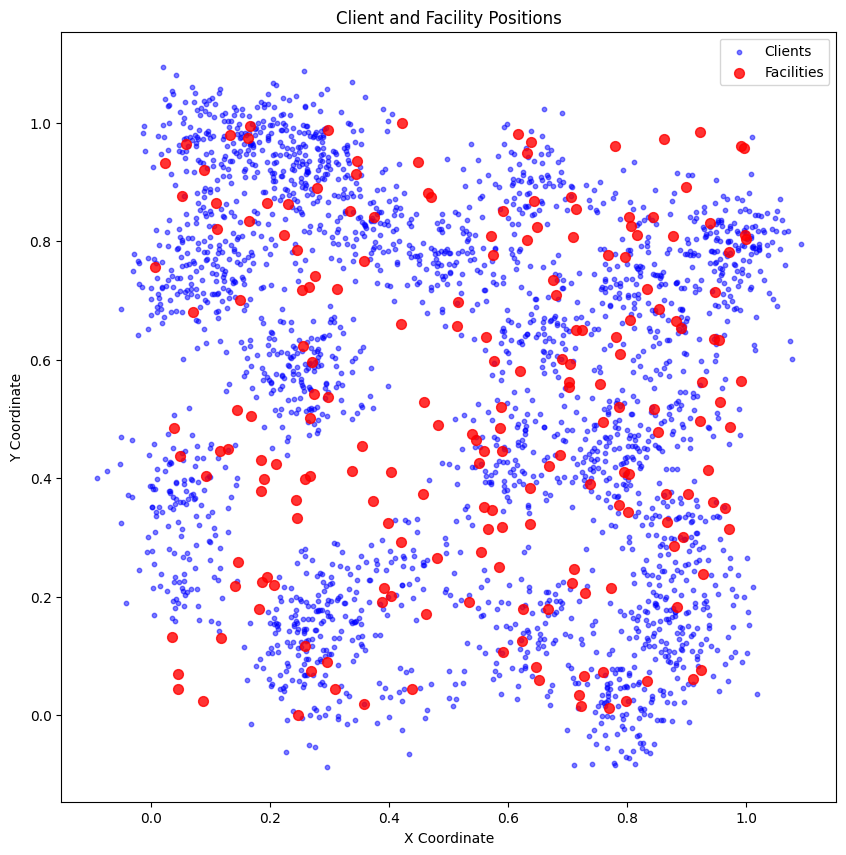

In [12]:
n_clients = 2500
n_facilities = 200
cli_pos, fac_pos = generate_positions(num_clients=n_clients, num_facilities=n_facilities, mode="clustered")
demands = np.random.uniform(0, 1, n_clients)
capacities = np.random.uniform(0, 1, n_facilities)
opening = capacities * np.random.uniform(0.8, 1.2, n_facilities)

plot_positions(cli_pos, fac_pos)

In [13]:
from utils import Constants

np.savez(
    Constants.baseInstanceDataPath,
    cli_pos=cli_pos,
    fac_pos=fac_pos,
    demands=demands,
    capacities=capacities,
    opening_costs=opening,
)

In [ ]:
arr = np.load(Constants.baseInstanceDataPath)
cli_pos2, fac_pos2 = arr["cli_pos"], arr["fac_pos"]

In [ ]:
plot_positions(cli_pos2, fac_pos2)